Use Case - customer segmentation for reatil store


In [10]:
#1. Import Libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [11]:
# 2. create datset
data = {
    'CustomerID' : range(1,11),
    'Annual Income(k$)': [15,16,17,35,45,70,75,80,85,40],
    'Spending Score(1-100)': [39,81,6,77,76,6,94,3,72,40]
}

In [12]:
#3. convert dictionary to pandas dataframe
df = pd.DataFrame(data)

In [13]:
print("Sample Customer Data:")
print(df.head())

Sample Customer Data:
   CustomerID  Annual Income(k$)  Spending Score(1-100)
0           1                 15                     39
1           2                 16                     81
2           3                 17                      6
3           4                 35                     77
4           5                 45                     76


In [14]:
X = df[['Annual Income(k$)','Spending Score(1-100)']].values

In [16]:
wcss = []

# try k from 1 to 10
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

C:\Users\anokh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\anokh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\anokh\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\anokh\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

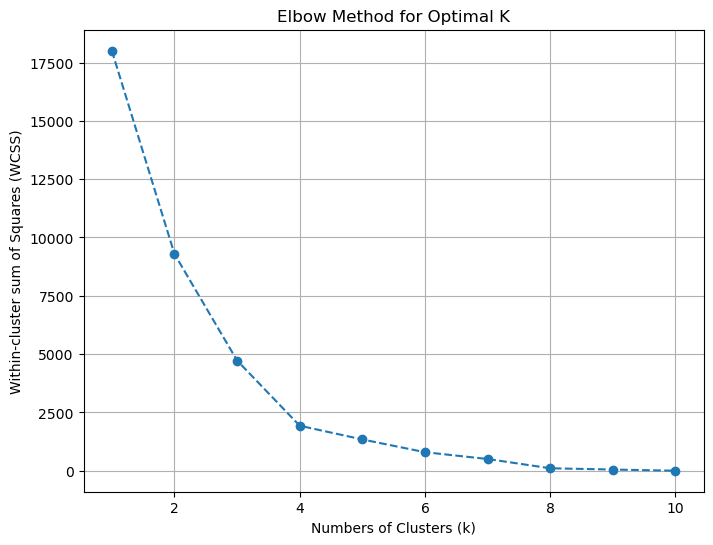

In [19]:
# plot the elbow curve
plt.figure(figsize=(8,6))
plt.plot(range(1,11), wcss, marker='o', linestyle='--')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Numbers of Clusters (k)")
plt.ylabel("Within-cluster sum of Squares (WCSS)")
plt.grid(True)
plt.show()

In [21]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state= 42)
kmeans.fit(X)

C:\Users\anokh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=42)

In [22]:
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

In [23]:
df['Cluster'] = labels

In [24]:
print("\n Customer Segments with cluster Labels:")
print(df)


 Customer Segments with cluster Labels:
   CustomerID  Annual Income(k$)  Spending Score(1-100)  Cluster
0           1                 15                     39        2
1           2                 16                     81        0
2           3                 17                      6        2
3           4                 35                     77        0
4           5                 45                     76        0
5           6                 70                      6        1
6           7                 75                     94        0
7           8                 80                      3        1
8           9                 85                     72        0
9          10                 40                     40        2


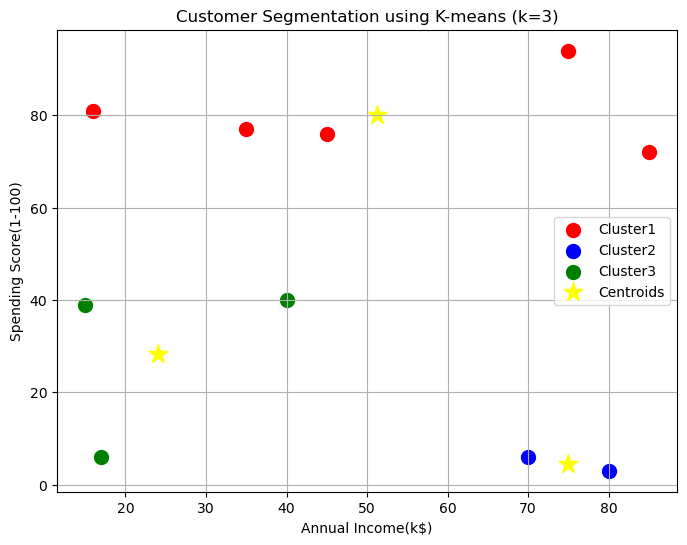

In [25]:
plt.figure(figsize=(8,6))

colors = ['red','blue','green']
for i in range(optimal_k):
    plt.scatter(X[labels == i, 0], X[labels == i, 1],
                s=100, c=colors[i], label=f'Cluster{i+1}')
# plot centroid
plt.scatter(centroids[:,0], centroids[:,1],
            s=200, c='yellow', marker='*', label='Centroids')

plt.title("Customer Segmentation using K-means (k=3)")
plt.xlabel("Annual Income(k$)")
plt.ylabel("Spending Score(1-100)")
plt.legend()
plt.grid(True)
plt.show()